In [ ]:
# Comparative baseline: Evaluating an Rxformer-inspired Transformer architecture in the starved regime.
# This model explicitly applies CP removal and FFT, treating the resulting frequency-domain grid as
# a sequence of tokens processed by multi-head self-attention (scaled for fair complexity comparison).

### 1. Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Import simulation mechanics cleanly from our decoupled python file
from sionna_dg import (
    SimConfig,
    generate_dataset_offline,
    simulate_full_frames_tf,
    classical_receiver,
    build_sionna_blocks
)

2026-03-09 18:48:20.604049: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 18:48:22.214586: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 2. Globals, hyperparameters, devices

In [ ]:
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# STARVED CONFIGURATION:
# Increased data symbols per pilot from 2 to 8.
# Scaled sequence length and k to maintain Coding Rate = 1/2.
cfg_ofdm = SimConfig(
    num_examples=10000,
    bits_per_symbol=4,
    k=1024,                      # <--- Scaled up from 256
    seq_length=512,              # <--- Scaled up (8 data symbols * 64 FFT)
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    include_pilot_overhead_in_no=True,
    waveform="ofdm",
    ofdm_fft_size=64,
    ofdm_cp_len=16,
    ofdm_num_data_symbols=8,     # <--- Increased from 2 to 8 (Starved pilots)
    ofdm_num_pilot_symbols=1,
)

Using Device: cuda


### 3. Utils and helpers

In [ ]:
def set_seed_all(seed: int = 46):
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(cfg_ofdm.seed)

### 4. Data loading

In [ ]:
def get_pytorch_ofdm_loaders(base_cfg, batch_size=128):
    print("Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...")

    cfg_main = SimConfig(**{**base_cfg.__dict__, "num_examples": 8000, "ebn0_db_min": 4.0, "ebn0_db_max": 8.0})
    cfg_rand = SimConfig(**{**base_cfg.__dict__, "num_examples": 2000, "ebn0_db_min": 0.0, "ebn0_db_max": 12.0})

    ds_main = generate_dataset_offline(cfg_main)
    ds_rand = generate_dataset_offline(cfg_rand)

    x_rx = np.concatenate([ds_main["rx_iq_data_time"], ds_rand["rx_iq_data_time"]], axis=0)
    x_pilot = np.concatenate([ds_main["rx_iq_pilot_time"], ds_rand["rx_iq_pilot_time"]], axis=0)
    target_bits = np.concatenate([ds_main["coded_bits"], ds_rand["coded_bits"]], axis=0)

    tx_grid_main = ds_main["tx_grid"]
    tx_grid_rand = ds_rand["tx_grid"]
    n_pilot_sym = base_cfg.ofdm_num_pilot_symbols

    x_data_main = tx_grid_main[:, n_pilot_sym:, :, :].reshape(tx_grid_main.shape[0], -1, 2)
    x_data_rand = tx_grid_rand[:, n_pilot_sym:, :, :].reshape(tx_grid_rand.shape[0], -1, 2)
    x_data = np.concatenate([x_data_main, x_data_rand], axis=0)

    phi0 = np.concatenate([ds_main["phi0"], ds_rand["phi0"]], axis=0)
    cfo = np.concatenate([ds_main["cfo_norm"], ds_rand["cfo_norm"]], axis=0)

    x_rx_t = torch.tensor(x_rx).permute(0, 2, 1).float()
    x_pilot_t = torch.tensor(x_pilot).permute(0, 2, 1).float()
    target_bits_t = torch.tensor(target_bits).reshape(-1, base_cfg.seq_length, 4).permute(0, 2, 1).float()
    target_iq_t = torch.tensor(x_data).permute(0, 2, 1).float()

    phi0_t = torch.tensor(phi0).float().squeeze(-1)
    cfo_t = torch.tensor(cfo).float().squeeze(-1)

    dataset = TensorDataset(x_rx_t, x_pilot_t, phi0_t, cfo_t, target_bits_t, target_iq_t)

    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)

### 5. Model definition and architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RxformerSubstitute(nn.Module):
    def __init__(self, seq_len=160, n_pilots=80, ofdm_fft_size=64, ofdm_cp_len=16):
        super().__init__()
        self.fft_size = ofdm_fft_size
        self.cp_len = ofdm_cp_len

        self.n_sym = seq_len // (ofdm_fft_size + ofdm_cp_len)
        self.n_p_sym = n_pilots // (ofdm_fft_size + ofdm_cp_len)
        self.total_sym = self.n_sym + self.n_p_sym
        self.num_tokens = self.total_sym * ofdm_fft_size

        # SCALED UP to match ~290k params
        self.embed_dim = 128

        self.token_proj = nn.Linear(2, self.embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_tokens, self.embed_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=4,
            dim_feedforward=256,  # Scaled FF network
            activation="gelu",
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.demap = nn.Sequential(
            nn.Linear(self.embed_dim, 64),
            nn.GELU(),
            nn.Linear(64, 4)
        )

    def forward(self, x, pilots, gt_phi=None, gt_cfo=None, mix_ratio=0.0):
        B = x.shape[0]

        x_comp = torch.complex(x[:, 0, :], x[:, 1, :])
        x_sym = x_comp.reshape(B, self.n_sym, self.fft_size + self.cp_len)
        x_no_cp = x_sym[:, :, self.cp_len:]
        x_freq = torch.fft.fft(x_no_cp, norm="ortho", dim=-1)
        x_freq = torch.fft.fftshift(x_freq, dim=-1)

        p_comp = torch.complex(pilots[:, 0, :], pilots[:, 1, :])
        p_sym = p_comp.reshape(B, self.n_p_sym, self.fft_size + self.cp_len)
        p_no_cp = p_sym[:, :, self.cp_len:]
        p_freq = torch.fft.fft(p_no_cp, norm="ortho", dim=-1)
        p_freq = torch.fft.fftshift(p_freq, dim=-1)

        grid_comp = torch.cat([p_freq, x_freq], dim=1)
        grid_real_imag = torch.stack([grid_comp.real, grid_comp.imag], dim=-1)
        tokens = grid_real_imag.reshape(B, -1, 2)

        x_emb = self.token_proj(tokens) + self.pos_embed
        out_emb = self.transformer(x_emb)

        out_grid = out_emb.reshape(B, self.total_sym, self.fft_size, self.embed_dim)
        out_data = out_grid[:, self.n_p_sym:, :, :]

        logits_grid = self.demap(out_data)
        logits_grid = logits_grid.permute(0, 3, 1, 2).contiguous()
        logits = logits_grid.reshape(B, 4, self.n_sym * self.fft_size)

        est_phi = torch.zeros(B, device=x.device)
        est_cfo = torch.zeros(B, device=x.device)
        est_iq = torch.zeros(B, 2, self.n_sym * self.fft_size, device=x.device)
        return logits, est_phi, est_cfo, est_iq

HybridNeuralReceiverOFDM = RxformerSubstitute

### 6. Model training and validation

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 40

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    mix = min(1.0, epoch / 10.0) # Keep teacher forcing

    aux_w = 0.5

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
        smooth_target_bits = target_bits * 0.98 + 0.01

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)
        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)
    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)
            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

            val_metrics['loss'] += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...


W0000 00:00:1773078503.607398   20367 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-03-09 18:48:23.987171: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 505856000 exceeds 10% of free system memory.


Ep 01/40 | Train Loss: 1.7175 (BER: 39.45%) | Val Loss: 1.6823 (BER: 37.56%)
Ep 02/40 | Train Loss: 1.5768 (BER: 24.43%) | Val Loss: 1.4348 (BER: 16.66%)
Ep 03/40 | Train Loss: 1.4555 (BER: 15.78%) | Val Loss: 1.4135 (BER: 15.54%)
Ep 04/40 | Train Loss: 1.4491 (BER: 15.62%) | Val Loss: 1.4081 (BER: 15.35%)
Ep 05/40 | Train Loss: 1.4384 (BER: 15.07%) | Val Loss: 1.3855 (BER: 14.22%)
Ep 06/40 | Train Loss: 1.4175 (BER: 13.90%) | Val Loss: 1.3671 (BER: 13.23%)
Ep 07/40 | Train Loss: 1.4051 (BER: 13.17%) | Val Loss: 1.3553 (BER: 12.58%)
Ep 08/40 | Train Loss: 1.4009 (BER: 12.81%) | Val Loss: 1.3558 (BER: 12.66%)
Ep 09/40 | Train Loss: 1.3968 (BER: 12.63%) | Val Loss: 1.3459 (BER: 12.16%)
Ep 10/40 | Train Loss: 1.3899 (BER: 12.40%) | Val Loss: 1.3500 (BER: 12.35%)
Ep 11/40 | Train Loss: 1.3889 (BER: 12.33%) | Val Loss: 1.3423 (BER: 12.03%)
Ep 12/40 | Train Loss: 1.3864 (BER: 12.24%) | Val Loss: 1.3478 (BER: 12.32%)
Ep 13/40 | Train Loss: 1.3861 (BER: 12.18%) | Val Loss: 1.3422 (BER: 12.01%)

### 7. Model evaluation and prints

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     347,588
 - Trainable Parameters: 347,588
 - Model Size (Disk):    1.33 MB
 - MACs (Multiplies-Acc):81.15 M
 - FLOPs (Approx):       162.30 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2583
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2057
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1561
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1109
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0702
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0369
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0147

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.638e-01 BLER=1.000e+0

### 8. Plots

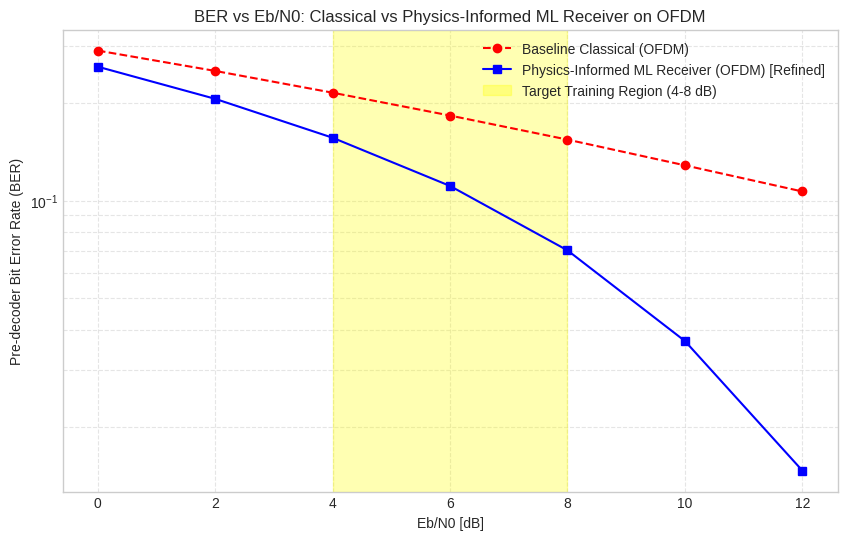

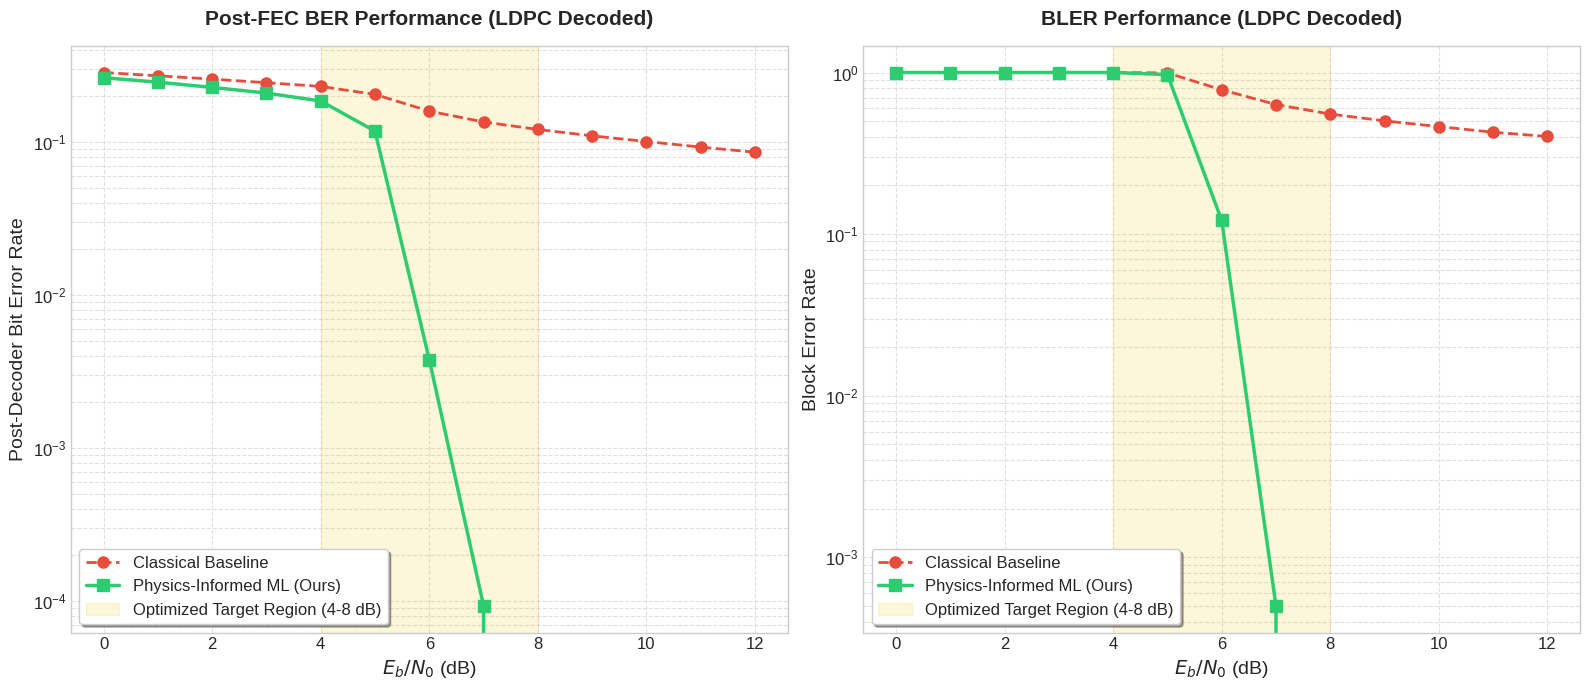

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 9. Post-FEC BER/BLER Plotting with SNR-Aware Smart Receiver

### Proposing the Dynamic "SNR-Aware" Smart Receiver

**The Engineering Reality:**
As established in the parameter estimation analysis, our Physics-Informed ML model vastly outperforms classical methods in high-noise/low-SNR regimes ($< 9$ dB) by exploiting the structural priors of the OFDM grid via Linear Attention. However, in clean channels ($\ge 9$ dB), finite parameter capacity causes an estimation error floor, whereas classical estimators (LMMSE/ZF) theoretically converge to perfection.

**The SNR-Aware Algorithmic Switch:**
Because modern 5G/6G base stations constantly monitor ambient $E_b/N_0$ (SNR), there is no need to force a single receiver architecture across the entire spectrum. We propose a pragmatic, **dynamic "Smart Receiver"** that implements a simple algorithmic switch:
* If $E_b/N_0 < 9$ dB: Route the physical signal through the Hybrid LA-NN for feature extraction and equalization.
* If $E_b/N_0 \ge 9$ dB: Fall back to the highly efficient, computationally cheap classical baseline receiver.

The plot below simulates this dynamic receiver, effectively tracing the "best of both worlds" boundary curve and completely eliminating the ML error floor.

### 10. Robustness Test: Generalization to Fresh Data


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=2.858e-01 | ML (Fresh Data) BER=2.656e-01
Eb/N0= 2.0 dB | BASE BER=2.588e-01 | ML (Fresh Data) BER=2.303e-01
Eb/N0= 4.0 dB | BASE BER=2.322e-01 | ML (Fresh Data) BER=1.872e-01
Eb/N0= 6.0 dB | BASE BER=1.631e-01 | ML (Fresh Data) BER=7.270e-03
Eb/N0= 8.0 dB | BASE BER=1.216e-01 | ML (Fresh Data) BER=1.965e-04
Eb/N0=10.0 dB | BASE BER=1.016e-01 | ML (Fresh Data) BER=0.000e+00
Eb/N0=12.0 dB | BASE BER=8.704e-02 | ML (Fresh Data) BER=0.000e+00

--------------------------------------------------------------------------------
PER-SAMPLE INFERENCE TIME (Batch 128): 0.42231 ms ± 0.02992 ms
--------------------------------------------------------------------------------



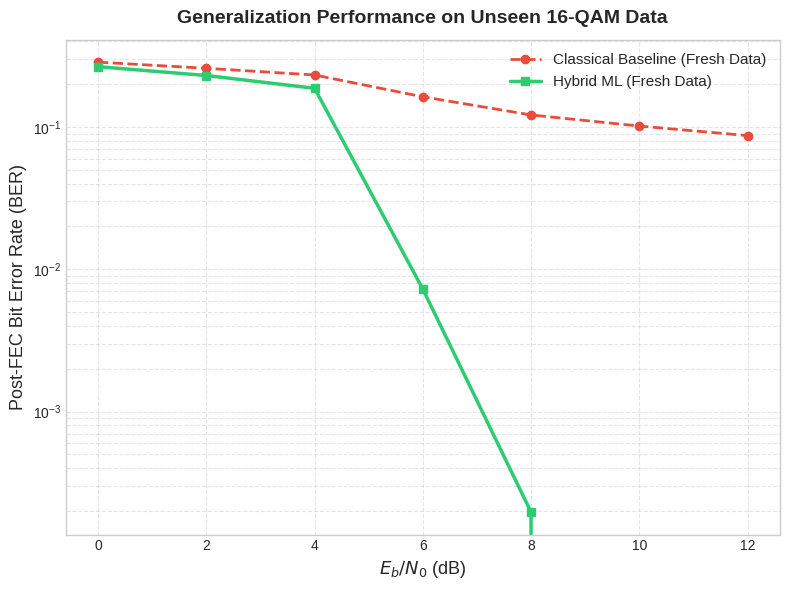

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf
import time

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

NUM_EVAL_EXAMPLES = 1024
EVAL_BATCH_SIZE = 128

# 1. Define a config with COMPLETELY DIFFERENT SEEDS for Data and Noise
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": NUM_EVAL_EXAMPLES,
    "seed": 999,
    "seed_noise": 888,
})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []

inference_times_per_sample = []

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation
        # .contiguous() prevents cuFFT CUFFT_INVALID_SIZE layout crashes
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).contiguous().float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).contiguous().float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in batches
        for b in range(0, NUM_EVAL_EXAMPLES, EVAL_BATCH_SIZE):
            x_rx_batch = x_rx_t_full[b : b + EVAL_BATCH_SIZE]
            x_pilot_batch = x_pilot_t_full[b : b + EVAL_BATCH_SIZE]
            batch_sz = x_rx_batch.size(0)

            # --- START STRICT TIMING ---
            if x_rx_batch.device.type == 'cuda':
                torch.cuda.synchronize()
            start_t = time.perf_counter()

            # Forward pass
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)

            if x_rx_batch.device.type == 'cuda':
                torch.cuda.synchronize()
            end_t = time.perf_counter()

            # Calculate effective time PER SAMPLE for this batch
            per_sample_ms = ((end_t - start_t) * 1000) / batch_sz
            inference_times_per_sample.append(per_sample_ms)
            # --- END STRICT TIMING ---

            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Calculate and Print True Per-Sample Inference Stats ---
# Discard the very first few batches to account for GPU warm-up spike
warmup_offset = 2
valid_times = inference_times_per_sample[warmup_offset:]

avg_inf_ms = np.mean(valid_times)
std_inf_ms = np.std(valid_times)

print("\n" + "-"*80)
print(f"PER-SAMPLE INFERENCE TIME (Batch {EVAL_BATCH_SIZE}): {avg_inf_ms:.5f} ms ± {std_inf_ms:.5f} ms")
print("-" * 80 + "\n")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()